In [21]:
! pip install scipy

  Using cached scipy-1.13.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.13.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)


In [56]:
import cfgrib
import xarray as xr

# Register the cfgrib engine

# Open the GRIB file
data = xr.open_dataset('/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2019060100.grib', engine='cfgrib')

# Display the dataset
print(data)


<xarray.Dataset>
Dimensions:     (step: 81, latitude: 1441, longitude: 2880)
Coordinates:
    time        datetime64[ns] ...
  * step        (step) timedelta64[ns] 0 days 03:00:00 ... 10 days 03:00:00
    surface     float64 ...
  * latitude    (latitude) float64 90.0 89.88 89.75 ... -89.75 -89.88 -90.0
  * longitude   (longitude) float64 0.0 0.125 0.25 0.375 ... 359.6 359.8 359.9
    valid_time  (step) datetime64[ns] ...
Data variables:
    tp          (step, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP 
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP 
    history:                 2024-07-03T17:42 GRIB to CDM+CF via cfgrib-0.9.1...


In [15]:
import xarray as xr

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2019060100.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract the variable of interest (tp)
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Check for zero values
zero_count = (variable == 0).sum().item()

if zero_count > 0:
    print(f'There are {zero_count} zero values in the data.')
else:
    print('There are no zero values in the data.')



There are 195234944 zero values in the data.


In [17]:
import xarray as xr

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2019060100.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract the variable of interest (tp)
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Display the available steps and prompt the user to enter the desired step index
steps = ds['step'].values
print("Available steps (timedelta64):")
for i, step in enumerate(steps):
    print(f"{i}: {step}")

step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(steps):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for analysis
data = variable.isel(step=step_index).values  # Convert to numpy array for analysis

# Check the total number of values
total_values = data.size

# Check for zero values
zero_count = (data == 0).sum()

print(f'The total number of values in the data at step {step_index} is {total_values}.')
print(f'There are {zero_count} zero values in the data at step {step_index}.')


Available steps (timedelta64):
0: 10800000000000 nanoseconds
1: 21600000000000 nanoseconds
2: 32400000000000 nanoseconds
3: 43200000000000 nanoseconds
4: 54000000000000 nanoseconds
5: 64800000000000 nanoseconds
6: 75600000000000 nanoseconds
7: 86400000000000 nanoseconds
8: 97200000000000 nanoseconds
9: 108000000000000 nanoseconds
10: 118800000000000 nanoseconds
11: 129600000000000 nanoseconds
12: 140400000000000 nanoseconds
13: 151200000000000 nanoseconds
14: 162000000000000 nanoseconds
15: 172800000000000 nanoseconds
16: 183600000000000 nanoseconds
17: 194400000000000 nanoseconds
18: 205200000000000 nanoseconds
19: 216000000000000 nanoseconds
20: 226800000000000 nanoseconds
21: 237600000000000 nanoseconds
22: 248400000000000 nanoseconds
23: 259200000000000 nanoseconds
24: 270000000000000 nanoseconds
25: 280800000000000 nanoseconds
26: 291600000000000 nanoseconds
27: 302400000000000 nanoseconds
28: 313200000000000 nanoseconds
29: 324000000000000 nanoseconds
30: 334800000000000 nanoseco

The total number of values in the data at step 1 is 4150080.
There are 2417315 zero values in the data at step 1.


In [39]:
! pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 7.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 46.8 MB/s eta 0:00:0000:0100:01


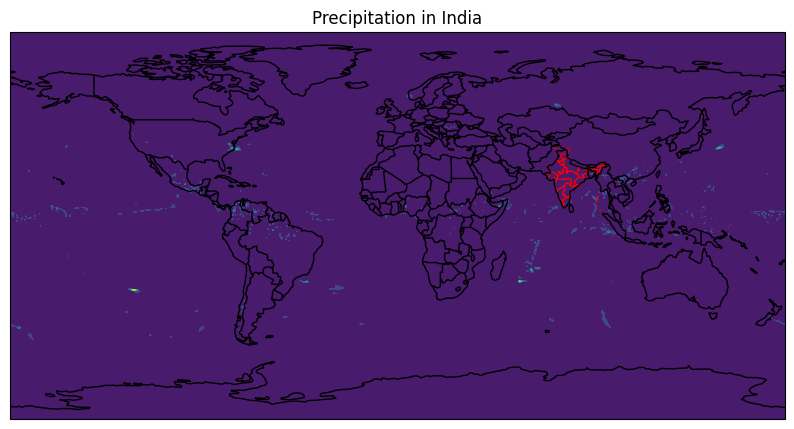

In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# Load your data (assuming already loaded)
# Replace 'tp' with your actual variable name
data_to_plot = data['tp']  # Assuming 'data' is your dataset
latitude = ds.variables['latitude'][:]
longitude = ds.variables['longitude'][:]
# Load the shapefile for India
india_shapefile = gpd.read_file('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx')

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data (example with contourf)
# Replace with your specific plotting method for your data
# Assuming 'longitude', 'latitude' are already defined from your dataset
plt.contourf(longitude, latitude, data_to_plot[0], transform=ccrs.PlateCarree(), cmap='viridis')

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Overlaying India shape
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Adding title and labels
plt.title('Precipitation in India')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


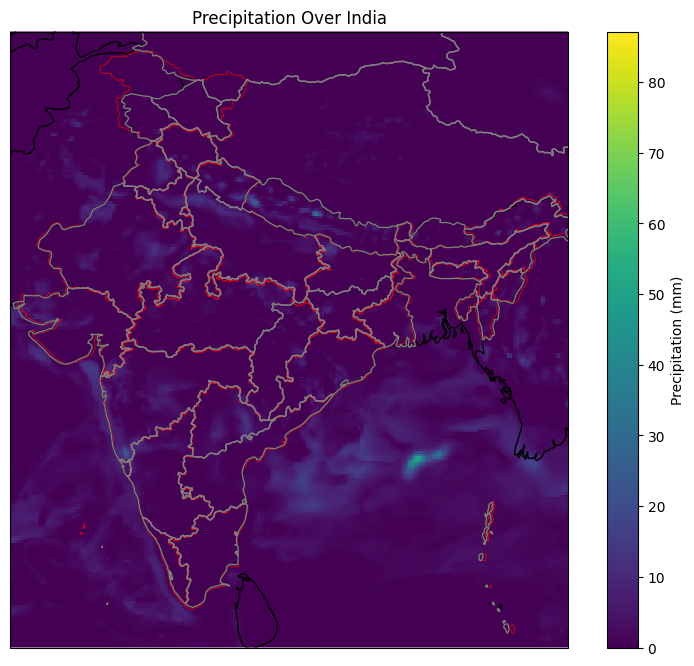

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2019090100.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest
level = ds.variables['step'][:]

# Select specific time and level for plotting (e.g., first time step and first level)
level_index = 0

data = variable[ level_index, :, :]

# Select specific time index for plotting (e.g., first time step)
  # Convert to numpy array for plotting

# Load the shapefile for India
india_shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx'
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a meshgrid for longitude and latitude
lon, lat = np.meshgrid(lon, lat)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data (example with pcolormesh)
cs = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap='viridis')

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, edgecolor='gray')

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Overlaying India shapefile
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable

# Adding title and labels
plt.title('Precipitation Over India')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


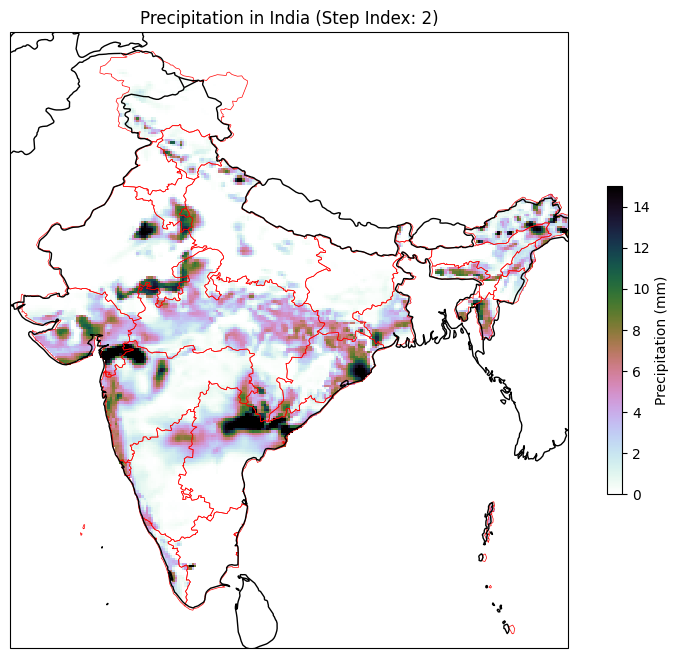

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2020081400.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Prompt the user to enter the desired step index
step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(ds['step']):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for plotting
data = variable.isel(step=step_index).values  # Convert to numpy array for plotting

# Load the shapefile for India
india_shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx'
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.union_all()

# Create a 2D mask by iterating over the meshgrid of lon and lat
lon_2d, lat_2d = np.meshgrid(lon, lat)
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :]] for lat in lat_2d[:, 0]])
masked_data = np.ma.masked_where(~mask, data)

# Clip the data to have a maximum value of 15
masked_data = np.clip(masked_data, None, 15)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking
cs = ax.pcolormesh(lon_2d, lat_2d, masked_data, transform=ccrs.PlateCarree(), cmap='cubehelix_r')

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Overlaying India shape
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Adding colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5)
cbar.set_label('Precipitation (mm)')

# Adding title and labels
plt.title(f'Precipitation in India (Step Index: {step_index})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


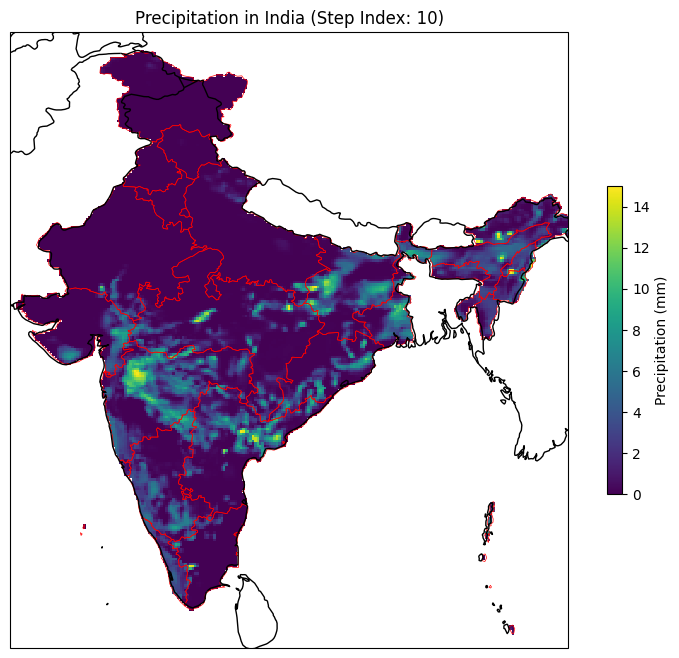

In [5]:
# import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2020091500.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Prompt the user to enter the desired step index
step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(ds['step']):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for plotting
data = variable.isel(step=step_index).values  # Convert to numpy array for plotting

# Load the shapefile for India
india_shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx'
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.union_all()

# Create a 2D mask by iterating over the meshgrid of lon and lat
lon_2d, lat_2d = np.meshgrid(lon, lat)
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :]] for lat in lat_2d[:, 0]])
masked_data = np.ma.masked_where(~mask, data)

# Clip the data to have a maximum value of 15
masked_data = np.clip(masked_data, None, 15)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking
cs = ax.pcolormesh(lon_2d, lat_2d, masked_data, transform=ccrs.PlateCarree(), cmap='viridis')

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Overlaying India shape
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Adding colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5)
cbar.set_label('Precipitation (mm)')

# Adding title and labels
plt.title(f'Precipitation in India (Step Index: {step_index})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


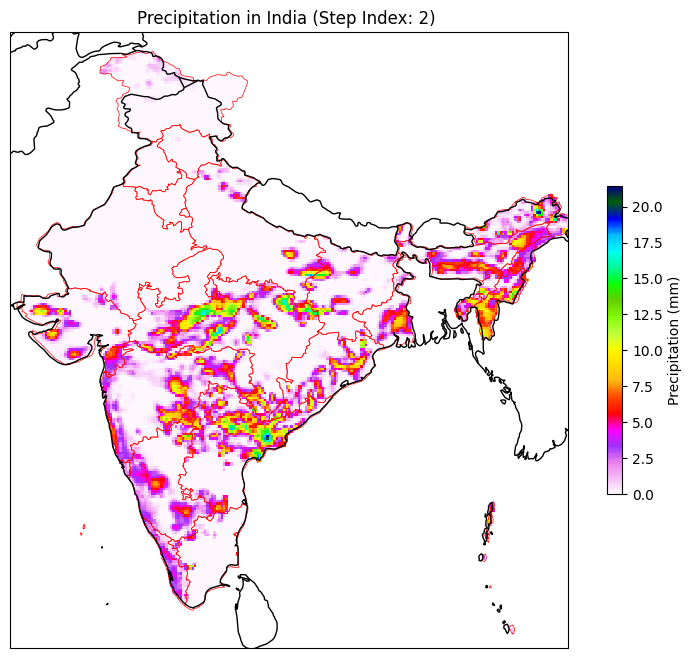

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2020091500.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Prompt the user to enter the desired step index
step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(ds['step']):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for plotting
data = variable.isel(step=step_index).values  # Convert to numpy array for plotting

# Load the shapefile for India
india_shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx'
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.union_all()

# Create a 2D mask by iterating over the meshgrid of lon and lat
lon_2d, lat_2d = np.meshgrid(lon, lat)
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :]] for lat in lat_2d[:, 0]])
masked_data = np.ma.masked_where(~mask, data)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking
cs = ax.pcolormesh(lon_2d, lat_2d, masked_data, transform=ccrs.PlateCarree(), cmap='gist_ncar_r')

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Overlaying India shape
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())


cbar = plt.colorbar(cs, orientation='vertical', pad=0.05,shrink=0.5)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable
  # Replace with the units of your variable

# Adding title and labels
plt.title(f'Precipitation in India (Step Index: {step_index}) ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


Maximum value of the variable at step 2: 127.8125
Minimum value of the variable at step 2: 0.0


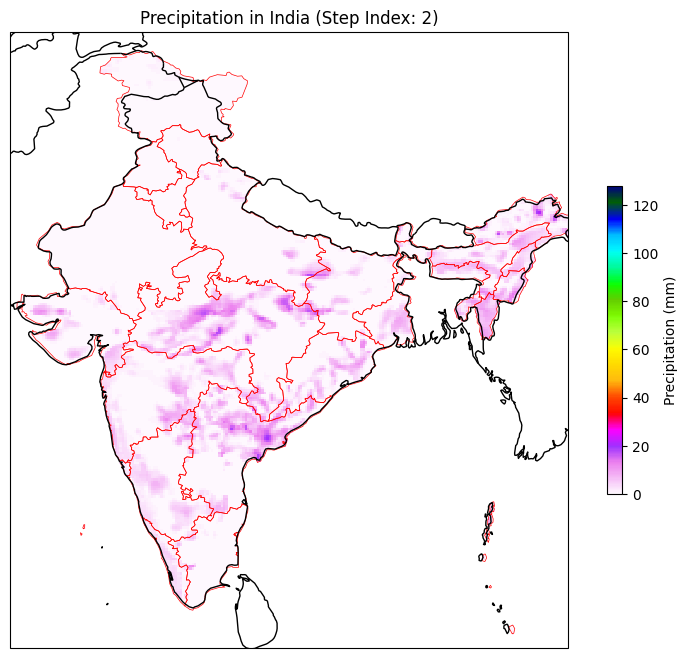

In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2020091500.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Prompt the user to enter the desired step index
step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(ds['step']):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for plotting
data = variable.isel(step=step_index).values  # Convert to numpy array for plotting

# Find the maximum and minimum values
max_value = np.nanmax(data)
min_value = np.nanmin(data)

print(f"Maximum value of the variable at step {step_index}: {max_value}")
print(f"Minimum value of the variable at step {step_index}: {min_value}")

# Load the shapefile for India
india_shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shx'
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.union_all()

# Create a 2D mask by iterating over the meshgrid of lon and lat
lon_2d, lat_2d = np.meshgrid(lon, lat)
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :]] for lat in lat_2d[:, 0]])
masked_data = np.ma.masked_where(~mask, data)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking and setting the color limits
cs = ax.pcolormesh(lon_2d, lat_2d, masked_data, transform=ccrs.PlateCarree(), cmap='gist_ncar_r', vmin=min_value, vmax=max_value)

# Adding coastlines and country borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

# Overlaying India shape
india_shapefile.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable

# Adding title and labels
plt.title(f'Precipitation in India (Step Index: {step_index})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


Maximum value of the variable at step 2: 111.0625
Minimum value of the variable at step 2: 0.0


/tmp/ipykernel_38237/3525308844.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  india_mask = india_shapefile.geometry.unary_union


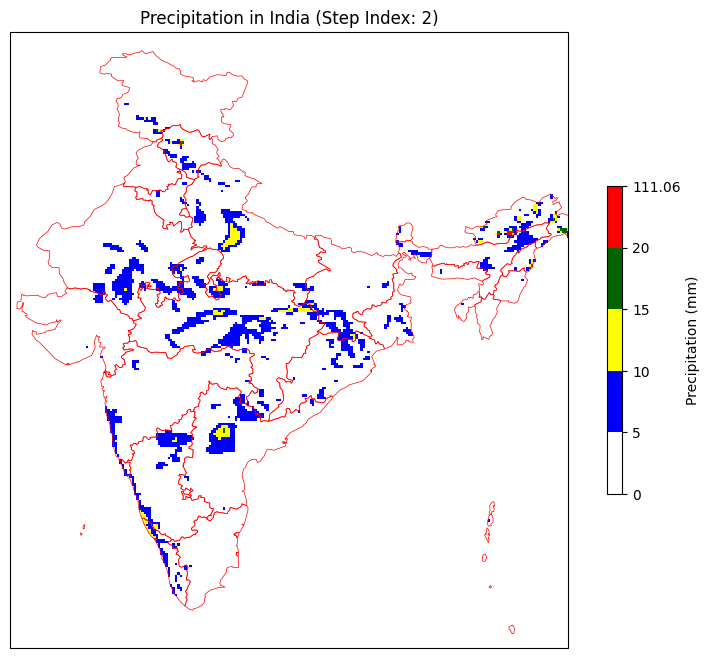

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.colors import BoundaryNorm, ListedColormap

# Load the NetCDF file
file_path = '/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2020081000.grib'
ds = xr.open_dataset(file_path, engine='cfgrib')

# Extract latitude, longitude, and the variable of interest (tp)
lat = ds['latitude'].values
lon = ds['longitude'].values
variable = ds['tp']  # Assuming 'tp' is the variable of interest

# Prompt the user to enter the desired step index
step_index = int(input("Enter the step index (0-80): "))
if step_index < 0 or step_index >= len(ds['step']):
    raise ValueError("Step index out of range. Please enter a value between 0 and 80.")

# Select the specific time step for plotting
data = variable.isel(step=step_index).values  # Convert to numpy array for plotting

# Find the maximum and minimum values
max_value = np.nanmax(data)
min_value = np.nanmin(data)

print(f"Maximum value of the variable at step {step_index}: {max_value}")
print(f"Minimum value of the variable at step {step_index}: {min_value}")

# Load the shapefile for India
india_shapefile_path = "/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shp"
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.unary_union

# Create a 2D mask by iterating over the meshgrid of lon and lat
lon_2d, lat_2d = np.meshgrid(lon, lat)
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :]] for lat in lat_2d[:, 0]])
masked_data = np.ma.masked_where(~mask, data)

# Define custom colormap and normalization
cmap = ListedColormap(['#FFFFFF', '#0000FF', '#FFFF00', '#006400', '#FF0000'])
norm = BoundaryNorm([0, 5, 10, 15, 20, max_value], ncolors=cmap.N, clip=True)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking and setting the color limits
cs = ax.pcolormesh(lon_2d, lat_2d, masked_data, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)

# Overlaying India shape
india_shapefile.boundary.plot(ax=ax, edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5, boundaries=[0, 25, 45, 75, 90, max_value])
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable
cbar.set_ticks([0, 5, 10, 15, 20, max_value])
cbar.set_ticklabels(['0', '5', '10', '15', '20', f'{max_value:.2f}'])

# Adding title and labels
plt.title(f'Precipitation in India (Step Index: {step_index})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


In [33]:
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

In [9]:
#to prepare old datasets that were executing properly

import xarray as xr
import numpy as np
import os
import pandas as pd

# Load NetCDF data
cfs_data = xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc",decode_times=False)
gpcp_data = xr.open_dataset(r'/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc',decode_times=False)

# Interpolate GPCP data to match the spatial resolution of CFS data
gpcp_data_interp = gpcp_data.interp(
    latitude=np.linspace(gpcp_data.latitude.min(), gpcp_data.latitude.max(), 32),
    longitude=np.linspace(gpcp_data.longitude.min(), gpcp_data.longitude.max(), 32),
    method="linear"
)

# Convert time coordinates to integer years
cfs_years = pd.to_datetime(cfs_data.time.values).year
gpcp_years = pd.to_datetime(gpcp_data_interp.time.values).year

# Prepare year-wise samples
train_years = np.arange(1981, 2005)
test_years = np.arange(2005, 2011)

# Prepare input and label arrays
train_inputs = []
train_labels = []
test_inputs = []
test_labels = []

for year in train_years:
    for ens in range(43):
        input_sample = cfs_data.cfs.sel(time=str(year),method='nearest').isel(z=slice(ens, ens+10)).values
        label_sample = gpcp_data_interp.pr.sel(time=str(year),method='nearest').values
        train_inputs.append(input_sample)
        train_labels.append(label_sample)

for year in test_years:
    for ens in range(43):
        input_sample = cfs_data.cfs.sel(time=str(year),method='nearest').isel(z=slice(ens, ens+10)).values
        label_sample = gpcp_data_interp.pr.sel(time=str(year),method='nearest').values
        test_inputs.append(input_sample)
        test_labels.append(label_sample)

# Convert lists to numpy arrays
train_inputs = np.array(train_inputs)
train_labels = np.array(train_labels)
test_inputs = np.array(test_inputs)
test_labels = np.array(test_labels)

# Save data as .npy files
os.makedirs("./Data", exist_ok=True)
np.save("./Data/inputdata100.npy", train_inputs)
np.save("./Data/label100.npy", train_labels)
np.save("./Data/test_inputdata.npy", test_inputs)
np.save("./Data/test_label.npy", test_labels)



In [4]:
cfs_years = pd.to_datetime(cfs_data.time.values).year
gpcp_years = pd.to_datetime(gpcp_data_interp.time.values).year

In [5]:
train_years = np.arange(1981, 2005)
test_years = np.arange(2005, 2011)

In [8]:
for year in train_years:
    for ens in range(43):
        input_sample = cfs_data.cfs.sel(time=str(year),method='nearest').isel(z=slice(ens, ens+10)).values
        label_sample = gpcp_data_interp.pr.sel(time=str(year),method='nearest').values
        train_inputs.append(input_sample)
        train_labels.append(label_sample)


In [ ]:
# start new

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask


# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


In [9]:
# ! pip install xarray cfgrib pandas
# import xarray as xr
# import pandas as pd

# Open the GRIB file using xarray and cfgrib
ds = xr.open_dataset('/home/hpcs_rnd/Montly_IMD_model_data/imdgfs_rain/gfsrain_2019060100.grib', engine='cfgrib')

# Convert the dataset to a pandas DataFrame
df = ds.to_dataframe().reset_index()

# Save the DataFrame to a CSV file
#df.to_csv('output_file.csv', index=False)

#print("Conversion complete. CSV file saved as 'output_file.csv'")
df.reset_index()

,index,step,latitude,longitude,time,surface,valid_time,tp
0,0,0 days 03:00:00,90.0,0.000,2019-06-01,0.0,2019-06-01 03:00:00,0.0
1,1,0 days 03:00:00,90.0,0.125,2019-06-01,0.0,2019-06-01 03:00:00,0.0
2,2,0 days 03:00:00,90.0,0.250,2019-06-01,0.0,2019-06-01 03:00:00,0.0
3,3,0 days 03:00:00,90.0,0.375,2019-06-01,0.0,2019-06-01 03:00:00,0.0
4,4,0 days 03:00:00,90.0,0.500,2019-06-01,0.0,2019-06-01 03:00:00,0.0
...,...,...,...,...,...,...,...,...
336156475,336156475,10 days 03:00:00,-90.0,359.375,2019-06-01,0.0,2019-06-11 03:00:00,0.0
336156476,336156476,10 days 03:00:00,-90.0,359.500,2019-06-01,0.0,2019-06-11 03:00:00,0.0
336156477,336156477,10 days 03:00:00,-90.0,359.625,2019-06-01,0.0,2019-06-11 03:00:00,0.0
336156478,336156478,10 days 03:00:00,-90.0,359.750,2019-06-01,0.0,2019-06-11 03:00:00,0.0


In [27]:
# df.drop(columns=['tp'],inplace=True)
df.describe()

,step,latitude,longitude,time,valid_time
count,336156480,3.361565e+08,3.361565e+08,336156480,336156480
mean,5 days 03:00:00,0.000000e+00,1.799375e+02,2019-06-01 00:00:00,2019-06-06 03:00:00.000115200
min,0 days 03:00:00,-9.000000e+01,0.000000e+00,2019-06-01 00:00:00,2019-06-01 03:00:00
25%,2 days 15:00:00,-4.500000e+01,8.996875e+01,2019-06-01 00:00:00,2019-06-03 15:00:00
50%,5 days 03:00:00,0.000000e+00,1.799375e+02,2019-06-01 00:00:00,2019-06-06 03:00:00
75%,7 days 15:00:00,4.500000e+01,2.699062e+02,2019-06-01 00:00:00,2019-06-08 15:00:00
max,10 days 03:00:00,9.000000e+01,3.598750e+02,2019-06-01 00:00:00,2019-06-11 03:00:00
std,2 days 22:08:33.762376779,5.199760e+01,1.039230e+02,NaN,NaN
